# A 70/30 RSI strategy over 5 years on 10 highly active US stocks

## Install and Import Libraries

In [34]:
!pip install yfinance pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

plt.style.use("default")

## Define Stocks & Download Data

In [36]:
# Top 10 active stocks (liquid, widely traded)
tickers = ["NVDA", "INTC", "ONDS", "PLUG", "AAL", "BMNR", "NOK", "SOFI", "NIO", "OPEN"]

# Download 5 years of data
data = yf.download(tickers, period="5y", group_by="ticker", auto_adjust=True)

data.head()

[*********************100%***********************]  10 of 10 completed


Ticker            NIO                                                  OPEN  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2021-03-17  41.900002  45.020000  41.330002  44.759998  96150000  25.500000   
2021-03-18  43.299999  44.259998  41.450001  41.630001  71159900  27.780001   
2021-03-19  41.439999  43.400002  40.439999  43.349998  97657200  26.378000   
2021-03-22  44.070000  44.560001  42.580002  42.939999  72838500  27.690001   
2021-03-23  42.580002  43.110001  40.980000  41.180000  58542300  27.299999   

Ticker                                              ...       NVDA             \
Price            High     Low      Close    Volume  ...       Open       High   
Date                                                ...                         
2021-03-17  28.360001  25.250  28.299999  14675200  ...  13.006965  13.419425   
2021-03-18  28.299999  26.150  26.809999  14034700  ...  13.103474  13.150854   
2021-03-19  28.500000  26.378  27.530001  32916500  ...  12.717944  12.889013   
2021-03-22  28.093000  27.010  27.900000   9986600  ...  12.880287  13.360826   
2021-03-23  27.500999  25.100  25.620001  14474100  ...  13.220925  13.310948   

Ticker                                            PLUG                        \
Price             Low      Close     Volume       Open       High        Low   
Date                                                                           
2021-03-17  12.956841  13.307707  243864000  37.029999  39.970001  34.200001   
2021-03-18  12.685029  12.690515  293896000  37.500000  38.570000  36.060001   
2021-03-19  12.580789  12.813453  299208000  35.000000  38.570000  34.500000   
2021-03-22  12.874302  13.153099  297804000  38.540001  39.450001  37.560001   
2021-03-23  12.988511  13.037887  222048000  38.230000  39.299999  36.439999   

Ticker                            
Price           Close     Volume  
Date                              
2021-03-17  39.330002  119530000  
2021-03-18  36.360001   39978400  
2021-03-19  38.279999   55298800  
2021-03-22  38.910000   24794800  
2021-03-23  36.790001   23159500  

[5 rows x 50 columns]

## RSI Calculation Function

In [37]:
def compute_rsi(series, window=14):
    delta = series.diff()
    
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

## Apply RSI & Generate Signals

In [38]:
results = {}

for ticker in tickers:
    df = data[ticker].copy()
    
    df["RSI"] = compute_rsi(df["Close"])
    df["Returns"] = df["Close"].pct_change()
    
    # Initialize
    position = 0          # 0 = flat, 1 = long
    positions = []        # track daily position
    trades = []           # track actual trades
    
    for i in range(len(df)):
        rsi = df["RSI"].iloc[i]
        
        # Entry condition: only buy if flat
        if position == 0 and rsi < 30:
            position = 1
            trades.append("BUY")
        
        # Exit condition: only sell if currently long
        elif position == 1 and rsi > 70:
            position = 0
            trades.append("SELL")
        
        else:
            trades.append(None)
        
        positions.append(position)
    
    df["Position"] = positions
    df["Trade"] = trades
    
    # Strategy returns (apply position from previous day)
    df["Strategy"] = df["Position"].shift(1) * df["Returns"]
    
    results[ticker] = df

## Trade Visualization

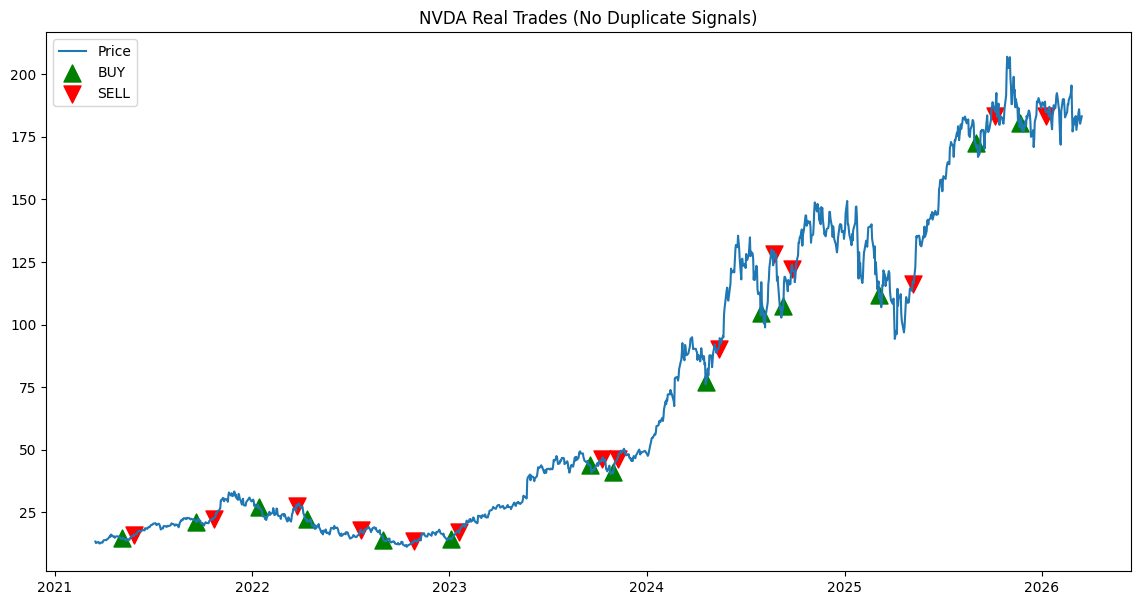

In [44]:
ticker = "NVDA"
df = results[ticker]

plt.figure(figsize=(14,7))
plt.plot(df["Close"], label="Price")

# Plot actual trades with bigger markers and offset
buy_points = df[df["Trade"] == "BUY"]
sell_points = df[df["Trade"] == "SELL"]

# Slightly shift the marker vertically so it is above/below the price line
plt.scatter(buy_points.index, buy_points["Close"] * 1.01,  # 1% above the price
            marker="^", color="green", s=150, label="BUY")  # s = size

plt.scatter(sell_points.index, sell_points["Close"] * 0.99,  # 1% below the price
            marker="v", color="red", s=150, label="SELL")

plt.title(f"{ticker} Real Trades (No Duplicate Signals)")
plt.legend()
plt.savefig(f"{ticker}_trades.png")
plt.show()

## Build Portfolio

In [40]:
portfolio_df = pd.DataFrame()

for ticker in tickers:
    df = results[ticker]
    portfolio_df[f"{ticker}_ret"] = df["Returns"]
    portfolio_df[f"{ticker}_strat"] = df["Strategy"]

strategy_cols = [col for col in portfolio_df.columns if "_strat" in col]
return_cols = [col for col in portfolio_df.columns if "_ret" in col]

portfolio_df["Portfolio_Strategy"] = portfolio_df[strategy_cols].mean(axis=1)
portfolio_df["Portfolio_BH"] = portfolio_df[return_cols].mean(axis=1)

portfolio_df.dropna(inplace=True)

## Portfolio Equity Curve

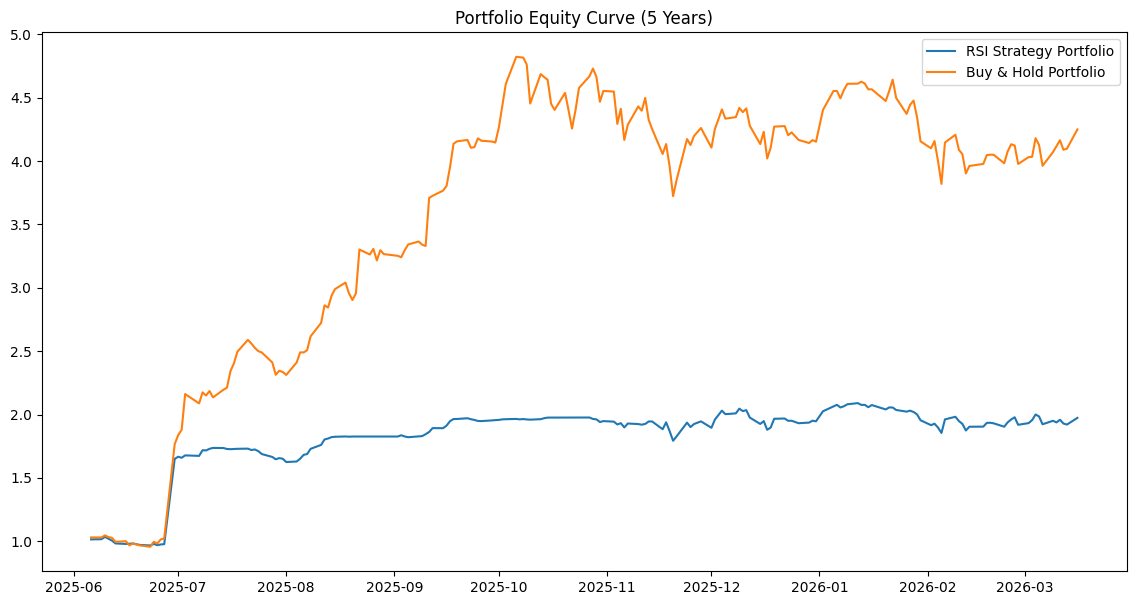

In [45]:
portfolio_df["Cum_Strategy"] = (1 + portfolio_df["Portfolio_Strategy"]).cumprod()
portfolio_df["Cum_BH"] = (1 + portfolio_df["Portfolio_BH"]).cumprod()

plt.figure(figsize=(14,7))
plt.plot(portfolio_df["Cum_Strategy"], label="RSI Strategy Portfolio")
plt.plot(portfolio_df["Cum_BH"], label="Buy & Hold Portfolio")

plt.title("Portfolio Equity Curve (5 Years)")
plt.legend()
plt.savefig("portfolio_equity_curve.png")
plt.show()

## Perfomance Metrics Table

In [42]:
def sharpe_ratio(returns):
    return returns.mean() / returns.std() * np.sqrt(252)

def fmt_pct(x):
    return f"{x * 100:.2f}%"

metrics = [
    ["Total Return",
     fmt_pct(portfolio_df["Cum_Strategy"].iloc[-1] - 1),
     fmt_pct(portfolio_df["Cum_BH"].iloc[-1] - 1)],

    ["Annual Return",
     fmt_pct(portfolio_df["Portfolio_Strategy"].mean() * 252),
     fmt_pct(portfolio_df["Portfolio_BH"].mean() * 252)],

    ["Volatility",
     fmt_pct(portfolio_df["Portfolio_Strategy"].std() * np.sqrt(252)),
     fmt_pct(portfolio_df["Portfolio_BH"].std() * np.sqrt(252))],

    ["Sharpe Ratio",
     f"{sharpe_ratio(portfolio_df['Portfolio_Strategy']):.2f}",
     f"{sharpe_ratio(portfolio_df['Portfolio_BH']):.2f}"]
]

print(tabulate(metrics, headers=["Metric", "RSI Strategy", "Buy & Hold"]))

Metric         RSI Strategy    Buy & Hold
-------------  --------------  ------------
Total Return   97.36%          324.90%
Annual Return  112.25%         223.40%
Volatility     81.56%          95.82%
Sharpe Ratio   1.38            2.33
